In [192]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import Tensor
import numpy as np
import torch.nn as nn
import kagglehub
import pandas as pd
import PIL.Image as Image
from torchvision import transforms

path = kagglehub.dataset_download("zalando-research/fashionmnist")

In [263]:
import torch 
import torch.nn as nn
import torch.nn.functional  as F
from torchvision import transforms
from functions import kernel

In [ ]:
F.conv2d()

- kernel size?? - 10 måske

F.conv2d laver convolution. skal bare give den kernel
den kernel den får er et en radialafhængig vægt ganget på hver pixel i den givne fourierbasis.
(hmm det betyde vel at vi ikke kan genbruge convolutionen til flere kernels, fordi den har ganget vægte på)

In [ ]:
class LiftingLayer(nn.Module):
    def __init__(self, in_features, out_features, bias=True):
        super(LiftingLayer, self).__init__()
        
        # Define learnable parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        
        if bias:
            self.bias = nn.Parameter(torch.randn(out_features))
        else:
            self.bias = None

    def forward(self, x):
        # x shape: (batch_size, in_features)
        #fourier folder 
        w = self.weight * fourier ???
        out = x @ w.t()  # matrix multiplication
        
        if self.bias is not None:
            out += self.bias
        
        return out

In [ ]:
theta = np.linspace(0, 2*np.pi, 100)
pixel_vals = np.sin(theta)

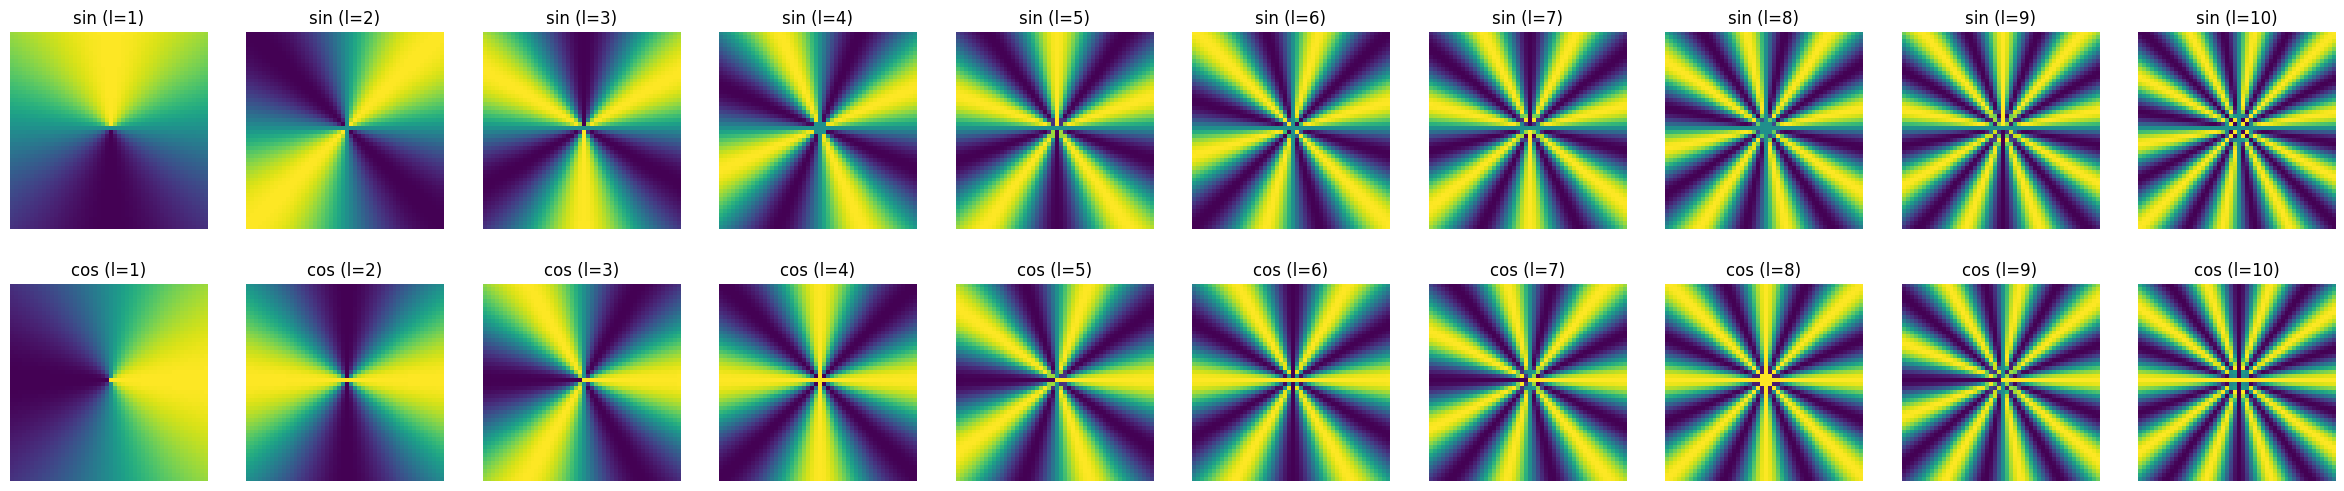

In [264]:

# #Her laver vi vores kernel funktion
# """ TODO: Vi skal skrive den med underfunktioner for læsbarhed """
# def kernel(kernel_size: int, l: int, plot: bool = False) ->  list:
#     """ Skaber l sin/cos kernels, som kan bruges til at lave cnn learning på.
#     Kan plotte hvis man vil:)"""
#     transform = transforms.ToTensor()
#     n = kernel_size
#     angle_map = np.zeros((n,n))
#     for x in range(int(-np.floor(n/2)), int(np.ceil(n/2))):    
#         for y in (range(int(-np.floor(n/2)), int(np.ceil(n/2)))):

#             if x == 0:
#                 if y > 0:
#                     thet = np.pi/2
#                 elif y < 0:
#                     thet = np.pi*3 /2
#                 else:
#                     thet = 0
#             else:
#                 thet = np.arctan(y/x)
#                 if x < 0:
#                     if y < 0:
#                         thet -= np.pi
#                     else:
#                         thet += np.pi
#             xx = x + int(np.floor(n/2))
#             yy = n - (y + int(np.floor(n/2))) -1

#             angle_map[yy,xx] = thet

#     lst = []
#     kernel_0 = np.ones((n,n))
#     lst.append(kernel_0)
#     for l_ in range(1,l+1):
#         kernel_sin = np.sin(l_*angle_map)
#         kernel_cos = np.cos(l_*angle_map)
#         kernel_sin = transform(kernel_sin)
#         kernel_cos = transform(kernel_cos)
#         lst.append(kernel_sin)
#         lst.append(kernel_cos)
#     if plot:
#         fig, axes = plt.subplots(2, l, figsize=(3 * l, 6))
#         if l == 1:
#             axes = axes.reshape(2, 1)
#         for l_ in range(1, l+1):
#             axes[0, l_ - 1].imshow(lst[2*l_ - 1].squeeze())
#             axes[0, l_ - 1].set_title(f"sin (l={l_})")
#             axes[0, l_ - 1].axis('off')
#             axes[1, l_ - 1].imshow(lst[2*l_].squeeze())
#             axes[1, l_ - 1].set_title(f"cos (l={l_})")
#             axes[1, l_ - 1].axis('off')
            
#         plt.show()
#     return lst


n = 50
listen = kernel(n,10,True)


- hvad gør vi med midterste pixel i kernel?

#evt fixes senere
- gør så vi også kan havw lige kernel sizes

# MNIST


In [261]:
#Laver vores MNIST image
RESIZE_SIZE = 280

df = pd.read_csv(path + '/fashion-mnist_train.csv')
row1 = df.iloc[0, 1:].values
pixel = row1.reshape(28,28).astype(np.uint8)

img = Image.fromarray(pixel)
print(img.resize((280, 280), Image.NEAREST))

transform = transforms.ToTensor()

img = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.NEAREST)

image = transform(img)


<PIL.Image.Image image mode=L size=280x280 at 0x1678D3080>


In [257]:
image.unsqueeze_(1)
image.shape

torch.Size([1, 1, 280, 280])

## Convolutions

In [258]:
temp = listen[-1].clone()
temp = temp.float()
temp.unsqueeze_(0)
temp.shape


torch.Size([1, 1, 50, 50])

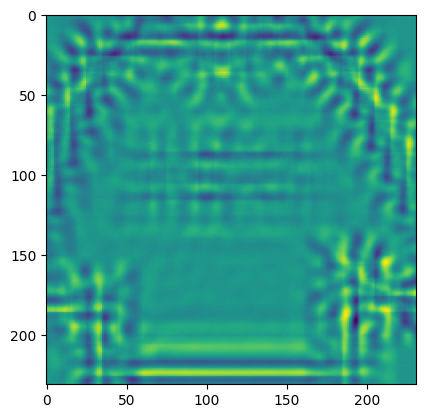

In [259]:
output = F.conv2d(input=image, weight=temp)

output.squeeze_()
output.shape
plt.imshow(output)